# Preparation for Lab 5 from Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab5_Antennas).

### Import libs

In [2]:
import numpy as np
from scipy.constants import Boltzmann

### Helper constants and functions

In [3]:
k_B = Boltzmann     # Boltzman constant
c0 = 3e8 #speed of light

db2lin = lambda db: 10**(db / 10)

lin2db = lambda g: 10 * np.log10(g)

lin2dBm = lambda g: lin2db(g/1e-3)

def scientific_2_str(value: float, unit: str = "Ω") -> str:
    prefixes = [
        (1e9, 'G'),
        (1e6, 'M'),
        (1e3, 'k'),
        (1, ''),
        (1e-3, 'm'),
        (1e-6, 'µ'),
        (1e-9, 'n'),
        (1e-12, 'p')    
    ]

    for factor, prefix in prefixes:
        if abs(value) >= factor:
            formatted = value / factor
            return f"{formatted:.3g} {prefix}{unit}"
    return f"{value:.3g} {unit}"  # fallback for very small values

## 5.1 Exercise 1

Calculate the expected gain of an horn antenna with dimensions $a^{'}$ = 2.3 cm, $b^{'}$ = 12 cm at f = 12 GHz.

From skipt page 10 we have the gain approximation for Horn Antennas with $ G = \frac{32a^{'}b^{'}}{\pi \lambda_{0}^{2} }$ where $a^{'}$ and $b^{'}$ being the dimensions of the extended horn antenna

In [4]:
### CONSTANTS ###
a = 2.3e-2 # meters
b = 12e-2 # meters
f = 12e9 #GHz
wavelength = c0 / f

## Gain calculation
gain = (32 * a * b ) / (np.pi * np.square(wavelength))
gaindb = lin2db(gain)
print(f"The approximated gain of the horn antenna with the given dimensions is: {gaindb:.2f} dB")

The approximated gain of the horn antenna with the given dimensions is: 16.53 dB


## 5.2 Exercise 2


You have to design a patch for the frequency f = 2 GHz. What are the length L and width W of the patch
on a Duroid substrate with the thickness d = 2.5mm and $\epsilon_{r}$ = 2.2?

The function for calculating the patch lengh is given with: 

L = $\frac{1}{2}$ $\cdot$ $\frac{c_{0}}{f \sqrt{\epsilon_{r}}}$ $\cdot$ $\alpha$ = $\frac{1}{2}$ $\cdot$ $\frac{c_{0}}{f\sqrt{\epsilon_{r}}}$ - 2 $\Delta L$ 


with $\alpha$ beeing the shortening factor.
$\Delta L$ is approximated with $\Delta L$ $\approx$ $\frac{d}{2}$.

For the calculation of the patch width, the following function is used: 
w = $ \frac{1}{2} \cdot \frac{c_{0}}{f} \cdot \sqrt{\frac{2}{\epsilon_{r}+1}}$

In [11]:
### CONSTANTS ###
d = 2.5e-3 
f = 2e9 #GHz
epsilon = 2.2
wavelength = c0 / f
deltaL =  d / 2

## Patch length calculation
length_m = ((0.5 * c0) / (f * np.sqrt(epsilon))) - 2 * deltaL
length_mm = length_m * 1000

## Patch width calculation
width = ((0.5 * c0) / f ) * np.sqrt(2 / (epsilon+1))
width_mm = width * 1000

print(f"The approximated length of the antenna patch with the given conditions is: {length_mm:.3f} mm")
print(f"The approximated width of the antenna patch with the given conditions is: {width_mm:.3f} mm")

The approximated length of the antenna patch with the given conditions is: 48.065 mm
The approximated width of the antenna patch with the given conditions is: 59.293 mm


## 5.3 Exercise 3

You have to design a phase shifter for a phase-driven array. Three pivoting angles are needed: $\theta$ = 90°,
$\theta$ = 70°, $\theta$ = 50°.
- Calculate the needed phase increments.
- Calculate the length of the needed coaxial lines (Teflon fill, $\epsilon_{r}$ = 2.2), to use them as phase shifters.
The distance between the elements is d = 75mm and the frequency is f = 2.0 GHz.

To calculate the needed phase increments, we use the formular $ \Delta \phi = - \frac{2\pi}{\lambda} \cdot d \cdot cos  \theta $, where d is the distance between two antennas.

In [6]:
### CONSTANTS ###
d = 75e-3 ##75mm
theta1 = 90 #90 degree
theta2 = 70 #70 degree
theta3 = 50 #50 degree
epsilon = 2.2
f = 2e9 #2 GHz
wavelength = c0 / f


### Calculation of the needed phase increment

## radiation direction theta1: 
phase_inc_1 = ((-2* np.pi) / wavelength) * d * np.cos(np.deg2rad(theta1))

## radiation direction theta2: 
phase_inc_2 = ((-2* np.pi) / wavelength) * d * np.cos(np.deg2rad(theta2))

## radiation direction theta3: 
phase_inc_3 = ((-2* np.pi) / wavelength) * d * np.cos(np.deg2rad(theta3))

print(f"The needed phase increment for angle theta 1 is: {phase_inc_1:.3f}.")
print(f"The needed phase increment for angle theta 2 is: {phase_inc_2:.3f}.")
print(f"The needed phase increment for angle theta 3 is: {phase_inc_3:.3f}.")


The needed phase increment for angle theta 1 is: -0.000.
The needed phase increment for angle theta 2 is: -1.074.
The needed phase increment for angle theta 3 is: -2.019.


In the following, we calculate the length of the needed coaxial lines, to use them as phase shifters. We calculate the length with the resulting phase increments from the task before and the equation  $ l =  \frac{\Delta \phi}{2 \pi} \cdot \frac{c_{0}}{f \cdot \sqrt{\epsilon_{r}} } $. Since a negative phase increment from left to right is a positive increment from right to left, we can just use the absolute value of the calculated length.

In [7]:
### Calculation of the needed line length to shift the phase by 0 to get the pivoting angle theta1: 
length1 = abs((phase_inc_1 / (2 * np.pi)) * (wavelength / np.sqrt(epsilon))) * 100

### Calculation of the needed line length to shift the phase by 1 to get the pivoting angle theta2: 
length2 = abs((phase_inc_2 / (2 * np.pi)) * (wavelength / np.sqrt(epsilon))) * 100

### Calculation of the needed line length to shift the phase by 2 to get the pivoting angle theta3: 
length3 = abs((phase_inc_3 / (2 * np.pi)) * (wavelength / np.sqrt(epsilon))) * 100

print(f"The necessary length of the wire to shift the phase far enough to reach pivoting angle theta1 is: {length1:.3f} mm.")
print(f"The necessary length of the wire to shift the phase far enough to reach pivoting angle theta2 is: {length2:.3f} mm.")
print(f"The necessary length of the wire to shift the phase far enough to reach pivoting angle theta3 is: {length3:.3f} mm.")


The necessary length of the wire to shift the phase far enough to reach pivoting angle theta1 is: 0.000 mm.
The necessary length of the wire to shift the phase far enough to reach pivoting angle theta2 is: 1.729 mm.
The necessary length of the wire to shift the phase far enough to reach pivoting angle theta3 is: 3.250 mm.


## 5.4 Exercise 4

The power radiation pattern for a horn antenna extended in the E-plane has to be calculated in the E-plane
( $\theta$ = 0) for angles from  $\theta$ = 0° to  $\theta$ = 180° and plotted in polar cooradinates.
- State the formulas to calculate the amplitudes in the far field and plot them in 1°-steps in a Matlab plot
(in dB).
- State the needed formulas and calculate the following values. Also, draw them by hand in your Matlab
plot.
– The first 4 nulls
– The half power beam width (approximative formula)
Dimensions of the antenna aperture: a = 2:3 cm, b = 12 cm, frequency f = 11.85 GHz.


### E-plane Radiation Pattern with Nulls and HPBW

This nex plot shows the normalized far-field radiation pattern of a horn antenna extended in the E-plane.  
The **red circles** mark the first four nulls w.r.t. the main lobe at 90°.  
The **green dots** indicate the **Half Power Beam Width (HPBW)** — the angular region where the radiated power is within 3 dB of the maximum (half power).
This region represents the main lobe of the antenna's radiation pattern.

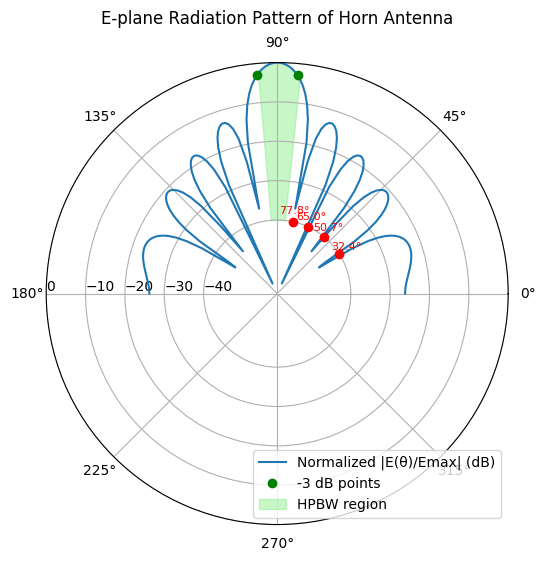

Wavelength λ = 2.532 cm
Approximate Half Power Beam Width (HPBW) ≈ 10.76°
First 4 nulls at angles (deg): ['77.82', '65.04', '50.73', '32.45']


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
c = 3e8  # speed of light in m/s
f = 11.85e9  # frequency in Hz
λ = c / f  # wavelength in meters
b_prime = 0.12  # aperture size in the E-plane (in meters)
beta = 2 * np.pi / λ  # wave number

# --- Angular range (0° to 180°) ---
theta_deg = np.arange(0, 181, 1)
theta_rad = np.radians(theta_deg)

# --- Compute B = (b' * beta * cos(theta)) / 2 ---
B = (b_prime * beta * np.cos(theta_rad)) / 2
B[B == 0] = 1e-12  # Avoid division by zero

# --- Compute normalized far-field amplitude |U(theta)/Umax| = |sin(B)/B| ---
U_norm = np.abs(np.sin(B) / B)
U_dB = 20 * np.log10(U_norm / np.max(U_norm))  # normalized in dB

# --- Compute approximate HPBW ---
HPBW = 51 * λ / b_prime  # in degrees

# --- Find first 4 nulls: B = nπ --> cos(θ_null) ---
null_angles = []
for n in range(1, 5):
    B_null = n * np.pi
    cos_theta_null = 2 * B_null / (b_prime * beta)
    if np.abs(cos_theta_null) <= 1:
        theta_null = np.degrees(np.arccos(cos_theta_null))
        null_angles.append(theta_null)

# --- Plot in polar coordinates ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Plot radiation pattern
ax.plot(np.radians(theta_deg), U_dB, label="Normalized |E(θ)/Emax| (dB)")

# Mark nulls
for angle in null_angles:
    ax.plot(np.radians(angle), [-40], 'ro')
    ax.text(np.radians(angle), -38, f'{angle:.1f}°', color='red', ha='center', fontsize=8)

# Mark -3 dB points (HPBW limits)
half_beam = HPBW / 2
left_bound = 90 - half_beam
right_bound = 90 + half_beam
ax.plot(np.radians(left_bound), [-3], 'go', label='-3 dB points')
ax.plot(np.radians(right_bound), [-3], 'go')

# Shade HPBW region in light green
theta_fill = np.radians(np.arange(int(left_bound), int(right_bound) + 1))
radius_fill = np.interp(theta_fill, np.radians(theta_deg), U_dB)
ax.fill_between(theta_fill, radius_fill, -40, color='lightgreen', alpha=0.5, label='HPBW region')

# Final plot settings
ax.set_title("E-plane Radiation Pattern of Horn Antenna", va='bottom')
ax.set_rticks([-40, -30, -20, -10, 0])
ax.set_rlabel_position(180)
ax.grid(True)
ax.legend(loc='lower right')
plt.show()

# --- Print Results ---
print("Wavelength λ = {:.3f} cm".format(λ * 100))
print("Approximate Half Power Beam Width (HPBW) ≈ {:.2f}°".format(HPBW))
print("First 4 nulls at angles (deg):", [f"{a:.2f}" for a in null_angles])

## 5.5 Exercise 5

You are building a 13 GHz communication link between two office buildings with two identical antennas.
The main beams of both antennas are oriented against each other. Both antennas have a gain of 9 dBi. The
transmit power $PT_{x}$ is 6dBm. The length of the communication link is 100m. Calculate the receive power
$PR_{x}$.
You observe that the system is not working. You hear from the manufacturer of the receiver that the receive
power must be at least $PR_{x}$ = -60dBm for the communication link to work. To reach this receive power,
only one antenna shall be exchanged. Calculate the gain of the new antenna (in dBi).

### Part 1: Calculate Received Power

This section uses the Friis transmission equation to calculate the received power at 13 GHz over a 100 m link using two antennas with 9 dBi gain. From the result, the minimum receive power is not achieved:

In [9]:
# --- Part 1: Compute received power with both antennas having 9 dBi gain ---

# Given values
c = 3e8  # speed of light [m/s]
f = 13e9  # frequency [Hz]
λ = c / f  # wavelength [m]
r = 100  # distance [m]
Pt_dBm = 6  # transmit power [dBm]
G1_dBi = 9  # gain of antenna 1 [dBi]
G2_dBi = 9  # gain of antenna 2 [dBi]

# Friis transmission formula in dB
path_loss_dB = 20 * np.log10(λ / (4 * np.pi * r))
Pr_dBm = Pt_dBm + G1_dBi + G2_dBi + path_loss_dB

# Output
print("=== PART 1 ===")
print(f"Wavelength λ = {λ*100:.2f} cm")
print(f"Path Loss = {path_loss_dB:.2f} dB")
print(f"Received Power = {Pr_dBm:.2f} dBm")

=== PART 1 ===
Wavelength λ = 2.31 cm
Path Loss = -94.72 dB
Received Power = -70.72 dBm


### Part 2: Determine Required Gain

This next section calculates the minimum gain needed for a replacement antenna to meet the link budget.

In [10]:
# --- Part 2: Compute required gain of new antenna if system doesn't meet threshold ---

Rx_min_dBm = -60  # minimum receive power for link to work

# Compute required gain of one antenna if only one is replaced
G_new_dBi = Rx_min_dBm - Pr_dBm + G1_dBi
print("\n=== PART 2 ===")
print(f"Minimum required gain of replacement antenna: {G_new_dBi:.2f} dBi")

# Optional: verify by recalculating received power
Pr_dBm_check = Pt_dBm + G1_dBi + G_new_dBi + path_loss_dB
print(f"Recomputed received power with new antenna: {Pr_dBm_check:.2f} dBm")



=== PART 2 ===
Minimum required gain of replacement antenna: 19.72 dBi
Recomputed received power with new antenna: -60.00 dBm
